# 200 — Validate fish-dollars baseline re-evaluation

**Purpose:** Before doing any ±10% transmissivity or probability-weighted uncertainty analysis, this notebook checks the most important thing:

> Can we take the **exact baseline Pareto-front pumping designs** from the original fish-dollars MOU run, send them back through the **same fish-dollars forward model**, and reproduce the archived objective values?

For the `fish_dollars` objective type, the original MOU objectives are:

1. `ag_receipts`
2. `fish_prob`

So this validation notebook compares those two values first. Depletion and total pumping are still useful diagnostics, but they are **not** the actual fish-dollars Pareto objectives.

## Success criterion

This notebook should produce very small differences between:

- `ag_receipts` from the Pareto archive summary
- `ag_receipts` from re-evaluation
- `fish_prob` from the Pareto archive summary
- `fish_prob` from re-evaluation

If this fails, we stop and debug here before doing the T uncertainty notebooks.

## 1) User settings

Run this notebook from:

`/workspaces/LPR_redux/LPR_pycap_opt/notebooks`

Only edit this first code cell if your folder names change.

In [1]:

from pathlib import Path
import sys
import os
import copy
import importlib.util
import traceback

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# User settings
# -----------------------------
RUN_NAME = "fish_dollars_baseline_0.0_1.0_0.01"

# Use all final-generation feasible front-1 members by default.
# To make a very fast smoke test, set N_TEST_MEMBERS = 5 or 10.
N_TEST_MEMBERS = None

# Conversion used in older postprocessing notebooks for pumping diagnostics.
GPM2CFS = 0.002228

# Numerical tolerances for validation.
# We keep a very strict test and also a practical test for floating-point reproducibility.
STRICT_FISH_PROB_ABS_TOL = 1.0e-8
STRICT_AG_RECEIPTS_REL_TOL = 1.0e-8

# Practical tolerances: these are still very tight, but they allow for tiny
# floating-point / ordering differences while preserving scientific equivalence.
PRACTICAL_FISH_PROB_ABS_TOL = 1.0e-6
PRACTICAL_AG_RECEIPTS_REL_TOL = 1.0e-5

# -----------------------------
# Robust repo paths
# -----------------------------
NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent
RUN_DIR = PROJECT_DIR / "pycap_runs" / "pycap_pest" / f"run_{RUN_NAME}"
SCRIPTS_DIR = PROJECT_DIR / "scripts"
OUTPUT_DIR = NOTEBOOK_DIR / "project_output" / "200_validate_fish_dollars_baseline_reevaluation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("NOTEBOOK_DIR:", NOTEBOOK_DIR)
print("PROJECT_DIR:", PROJECT_DIR)
print("RUN_DIR:", RUN_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

NOTEBOOK_DIR: /workspaces/LPR_redux/LPR_pycap_opt/notebooks
PROJECT_DIR: /workspaces/LPR_redux/LPR_pycap_opt
RUN_DIR: /workspaces/LPR_redux/LPR_pycap_opt/pycap_runs/pycap_pest/run_fish_dollars_baseline_0.0_1.0_0.01
OUTPUT_DIR: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/200_validate_fish_dollars_baseline_reevaluation


## 2) Load the original fish-dollars forward model

This is the key design choice.

Instead of re-coding the fish-dollars logic from scratch, this notebook imports the original forward-run script that PEST++-MOU used. That script already knows how to:

- read `LPR_Redux.yml`
- read `allobs.out.ins`
- read `Brook.csv`
- read `wells_and_receipts.csv`
- apply the fish-dollars low-pumping cutoff rule
- run PyCap
- calculate `fish_prob`
- calculate `ag_receipts`

That makes the original script the **source of truth** for validation.

In [2]:

def import_python_file(module_name: str, file_path: Path):
    """Import a Python file by path without permanently changing the repo."""
    file_path = Path(file_path)
    if not file_path.exists():
        raise FileNotFoundError(f"Could not find Python file: {file_path}")
    spec = importlib.util.spec_from_file_location(module_name, file_path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module
    spec.loader.exec_module(module)
    return module

# Prefer the copy inside the run folder because that is exactly what the MOU run used.
# Fall back to ../scripts if needed.
candidate_scripts = [
    RUN_DIR / "run_pycap_standalone_opt_mou_fish_dollars.py",
    SCRIPTS_DIR / "run_pycap_standalone_opt_mou_fish_dollars.py",
]

for candidate in candidate_scripts:
    if candidate.exists():
        FISH_DOLLARS_SCRIPT = candidate
        break
else:
    raise FileNotFoundError("Could not find run_pycap_standalone_opt_mou_fish_dollars.py in run folder or scripts folder.")

fish_dollars = import_python_file("fish_dollars_forward", FISH_DOLLARS_SCRIPT)
print("Using fish-dollars source-of-truth script:")
print(FISH_DOLLARS_SCRIPT)

Using fish-dollars source-of-truth script:
/workspaces/LPR_redux/LPR_pycap_opt/pycap_runs/pycap_pest/run_fish_dollars_baseline_0.0_1.0_0.01/run_pycap_standalone_opt_mou_fish_dollars.py


## 3) Helper functions

In [3]:

def read_pareto_archive_summary(run_name: str, run_dir: Path) -> pd.DataFrame:
    pareto_file = Path(run_dir) / f"{run_name}.pareto.archive.summary.csv.zip"
    if not pareto_file.exists():
        raise FileNotFoundError(f"Missing Pareto archive summary: {pareto_file}")
    df = pd.read_csv(pareto_file)
    df["member"] = df["member"].astype(str)
    return df


def select_final_feasible_front1(pareto_df: pd.DataFrame, n_test_members=None) -> pd.DataFrame:
    required = {"member", "generation", "nsga2_front", "is_feasible", "ag_receipts", "fish_prob"}
    missing = required - set(pareto_df.columns)
    if missing:
        raise KeyError(f"Pareto archive summary is missing required columns: {sorted(missing)}")

    df = pareto_df.loc[
        (pareto_df["nsga2_front"] == 1) &
        (pareto_df["is_feasible"] == 1)
    ].copy()

    final_generation = df["generation"].max()
    df = df.loc[df["generation"] == final_generation].copy()
    df["member"] = df["member"].astype(str)

    if n_test_members is not None:
        df = df.head(int(n_test_members)).copy()

    if df.empty:
        raise ValueError("No final-generation feasible front-1 members found.")

    return df


def load_decision_variable_population(run_dir: Path) -> pd.DataFrame:
    """
    Load saved decision-variable populations from the MOU run.

    We intentionally include both archive and non-archive dv_pop files, plus initial_dvpop.csv when present,
    because final Pareto members can come from any saved population.
    """
    run_dir = Path(run_dir)
    dv_files = sorted(run_dir.glob("*dv_pop.csv.zip"))
    frames = []

    for f in dv_files:
        try:
            frames.append(pd.read_csv(f, index_col=0))
        except Exception as err:
            print(f"Warning: could not read {f.name}: {err}")

    init_file = run_dir / "initial_dvpop.csv"
    if init_file.exists():
        frames.append(pd.read_csv(init_file, index_col=0))

    if not frames:
        raise FileNotFoundError(f"No dv_pop csv files were found in {run_dir}")

    dv_df = pd.concat(frames, axis=0)
    dv_df.index = dv_df.index.astype(str)
    dv_df = dv_df[~dv_df.index.duplicated(keep="first")]
    return dv_df


def get_q_columns(df: pd.DataFrame) -> list[str]:
    return [c for c in df.columns if str(c).lower().endswith("__q") or "_q" in str(c).lower()]


def effective_q_after_fish_dollars_cutoff(q_row: pd.Series, receipts: pd.DataFrame) -> pd.Series:
    """
    Reproduce the fish-dollars pumping cutoff used by the original forward model:
    if a pumping decision is <= 70% of baseline parval1, set that Q to zero.
    """
    q = q_row.copy()
    q.index = [str(i).lower() for i in q.index]
    q = q.loc[q.index.str.contains("_q")]
    local_receipts = receipts.loc[q.index]
    q.loc[q <= 0.7 * local_receipts.parval1] = 0.0
    return q


def run_original_fish_dollars_get_results(q_row: pd.Series, initial_dict_master, bdplobs, fishcurve, ref_flow, receipts):
    """
    Call the original fish-dollars get_results() function.

    We pass a deep copy of the initial dictionary each time to avoid cross-member mutation.
    The original script used a shallow copy internally, but because every member supplies all Q values,
    a deep copy should be equivalent and safer for notebook debugging.
    """
    q_row = q_row.copy()
    q_row.index = [str(i).lower() for i in q_row.index]
    obsnames = [i.split("!")[1].lower() for i in open(RUN_DIR / "allobs.out.ins", "r").readlines()[1:]]
    result = fish_dollars.get_results(
        q_row,
        obsnames,
        copy.deepcopy(initial_dict_master),
        bdplobs,
        fishcurve,
        ref_flow,
        receipts,
        write_csv=False,
    )
    return result

## 4) Load source data

In [4]:

# The original instantiate() function uses relative paths, so run it from RUN_DIR.
original_cwd = Path.cwd()
os.chdir(RUN_DIR)
try:
    initial_dict_master, bdplobs, fishcurve, ref_flow, receipts = fish_dollars.instantiate()
finally:
    os.chdir(original_cwd)

pareto_archive = read_pareto_archive_summary(RUN_NAME, RUN_DIR)
pareto_final = select_final_feasible_front1(pareto_archive, n_test_members=N_TEST_MEMBERS)
dv_df = load_decision_variable_population(RUN_DIR)

q_cols = get_q_columns(dv_df)
missing_members = sorted(set(pareto_final["member"]) - set(dv_df.index.astype(str)))

print("Pareto archive rows:", len(pareto_archive))
print("Final feasible front-1 rows selected:", len(pareto_final))
print("Final generation:", pareto_final["generation"].max())
print("Decision-variable population rows:", len(dv_df))
print("Q columns:", len(q_cols))
print("Base T:", initial_dict_master["project_properties"].get("T"))
print("Reference flow:", ref_flow)
print("bdpl observations:", len(bdplobs))
print("Missing final members in dv_df:", len(missing_members))

if missing_members:
    raise KeyError(f"Missing Pareto members in dv_pop files. First few: {missing_members[:10]}")

Pareto archive rows: 5669
Final feasible front-1 rows selected: 174
Final generation: 50
Decision-variable population rows: 6528
Q columns: 327
Base T: 1700.0
Reference flow: 8.6
bdpl observations: 330
Missing final members in dv_df: 0


## 5) Re-evaluate final Pareto members with the original fish-dollars model

This cell may take a bit because it runs PyCap once per selected Pareto member.

In [5]:

records = []
errors = []

for i, row in pareto_final.reset_index(drop=True).iterrows():
    member = str(row["member"])
    if (i == 0) or ((i + 1) % 25 == 0) or (i + 1 == len(pareto_final)):
        print(f"Re-evaluating member {i + 1} of {len(pareto_final)}: {member}")

    q_row = dv_df.loc[member, q_cols].copy()

    try:
        reeval = run_original_fish_dollars_get_results(
            q_row,
            initial_dict_master,
            bdplobs,
            fishcurve,
            ref_flow,
            receipts,
        )

        q_eff = effective_q_after_fish_dollars_cutoff(q_row, receipts)

        records.append({
            "member": member,
            "generation": row["generation"],
            "ag_receipts_archive": row["ag_receipts"],
            "fish_prob_archive": row["fish_prob"],
            "ag_receipts_reeval": reeval.loc["ag_receipts"],
            "fish_prob_reeval": reeval.loc["fish_prob"],
            "raw_total_pumping_gpm": q_row.sum(),
            "effective_total_pumping_gpm": q_eff.sum(),
            "effective_total_pumping_cfs": q_eff.sum() * GPM2CFS,
            "lpr_total_combined_bdpl_cfs": reeval.loc["lpr:total_combined:bdpl"] if "lpr:total_combined:bdpl" in reeval.index else np.nan,
        })
    except Exception as err:
        errors.append({
            "member": member,
            "error": repr(err),
            "traceback": traceback.format_exc(),
        })

comparison = pd.DataFrame(records)
error_df = pd.DataFrame(errors)

print("Successful re-evaluations:", len(comparison))
print("Errors:", len(error_df))

if not error_df.empty:
    display(error_df.head())

comparison.head()

Re-evaluating member 1 of 174: gen=47_member=5907_pso
Re-evaluating member 25 of 174: gen=45_member=5670_pso
Re-evaluating member 50 of 174: gen=41_member=5214_pso
Re-evaluating member 75 of 174: gen=32_member=3978_pso
Re-evaluating member 100 of 174: gen=47_member=5999_pso
Re-evaluating member 125 of 174: gen=43_member=5440_pso
Re-evaluating member 150 of 174: gen=34_member=4241_pso
Re-evaluating member 174 of 174: gen=50_member=6385_pso
Successful re-evaluations: 174
Errors: 0


,member,generation,ag_receipts_archive,fish_prob_archive,ag_receipts_reeval,fish_prob_reeval,raw_total_pumping_gpm,effective_total_pumping_gpm,effective_total_pumping_cfs,lpr_total_combined_bdpl_cfs
0,gen=47_member=5907_pso,50,9738960.0,0.719193,9.738960e+06,0.719193,42427.949226,41736.549128,92.989031,1.424825
1,56,50,12446400.0,0.533346,1.244640e+07,0.533346,52637.152842,52637.152842,117.275577,4.797320
2,64,50,12377800.0,0.567550,1.237783e+07,0.567550,52241.562957,52241.562957,116.394202,4.457265
3,gen=40_member=5105_pso,50,12283000.0,0.583854,1.228305e+07,0.583854,51868.902507,51444.954579,114.619359,4.281098
4,30,50,12433400.0,0.544694,1.243337e+07,0.544694,52187.234035,52187.234035,116.273157,4.690662


## 6) Calculate differences and pass/fail diagnostics

In [6]:
if comparison.empty:
    raise RuntimeError("No members were successfully re-evaluated.")

comparison["ag_receipts_diff"] = comparison["ag_receipts_reeval"] - comparison["ag_receipts_archive"]
comparison["fish_prob_diff"] = comparison["fish_prob_reeval"] - comparison["fish_prob_archive"]

comparison["ag_receipts_abs_diff"] = comparison["ag_receipts_diff"].abs()
comparison["fish_prob_abs_diff"] = comparison["fish_prob_diff"].abs()

comparison["ag_receipts_rel_diff"] = comparison["ag_receipts_abs_diff"] / comparison["ag_receipts_archive"].abs().replace(0, np.nan)

max_ag_abs = comparison["ag_receipts_abs_diff"].max()
max_ag_rel = comparison["ag_receipts_rel_diff"].max()
max_fish_abs = comparison["fish_prob_abs_diff"].max()

strict_validation_passed = bool(
    (max_ag_rel <= STRICT_AG_RECEIPTS_REL_TOL)
    and (max_fish_abs <= STRICT_FISH_PROB_ABS_TOL)
    and error_df.empty
)

practical_validation_passed = bool(
    (max_ag_rel <= PRACTICAL_AG_RECEIPTS_REL_TOL)
    and (max_fish_abs <= PRACTICAL_FISH_PROB_ABS_TOL)
    and error_df.empty
)

print("Max ag_receipts absolute difference:", max_ag_abs)
print("Max ag_receipts relative difference:", max_ag_rel)
print("Max fish_prob absolute difference:", max_fish_abs)
print("Strict validation passed:", strict_validation_passed)
print("Practical validation passed:", practical_validation_passed)

summary = pd.DataFrame({
    "metric": [
        "n_members_attempted",
        "n_members_successful",
        "n_members_error",
        "max_ag_receipts_abs_diff",
        "max_ag_receipts_rel_diff",
        "max_fish_prob_abs_diff",
        "strict_ag_receipts_rel_tol",
        "strict_fish_prob_abs_tol",
        "practical_ag_receipts_rel_tol",
        "practical_fish_prob_abs_tol",
        "strict_validation_passed",
        "practical_validation_passed",
    ],
    "value": [
        len(pareto_final),
        len(comparison),
        len(error_df),
        max_ag_abs,
        max_ag_rel,
        max_fish_abs,
        STRICT_AG_RECEIPTS_REL_TOL,
        STRICT_FISH_PROB_ABS_TOL,
        PRACTICAL_AG_RECEIPTS_REL_TOL,
        PRACTICAL_FISH_PROB_ABS_TOL,
        strict_validation_passed,
        practical_validation_passed,
    ]
})

display(summary)


Max ag_receipts absolute difference: 49.649860637262464
Max ag_receipts relative difference: 4.7232095872037674e-06
Max fish_prob absolute difference: 4.940429674249458e-07
Strict validation passed: False
Practical validation passed: True


,metric,value
0,n_members_attempted,174
1,n_members_successful,174
2,n_members_error,0
3,max_ag_receipts_abs_diff,49.649861
4,max_ag_receipts_rel_diff,0.000005
5,max_fish_prob_abs_diff,0.0
6,strict_ag_receipts_rel_tol,0.0
7,strict_fish_prob_abs_tol,0.0
8,practical_ag_receipts_rel_tol,0.00001
9,practical_fish_prob_abs_tol,0.000001


## 7) Plots

These are quick visual checks. The points should fall directly on the 1:1 line.

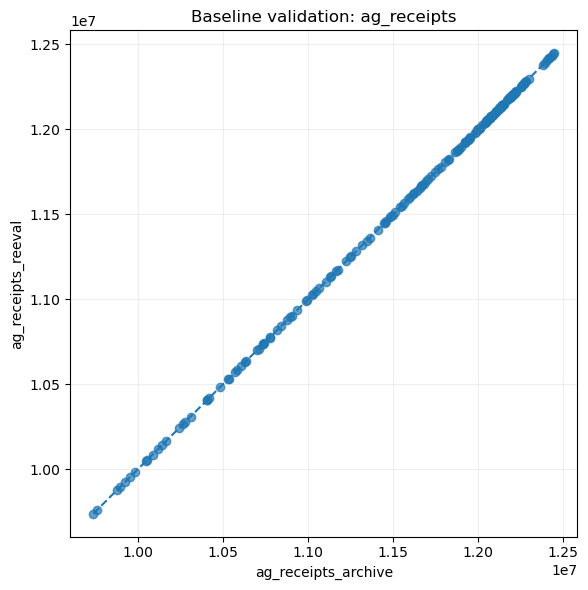

Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/200_validate_fish_dollars_baseline_reevaluation/200_validation_ag_receipts_one_to_one.png


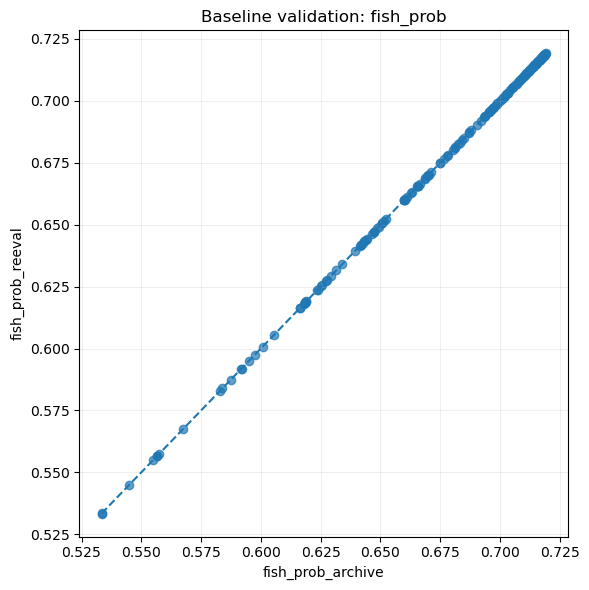

Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/200_validate_fish_dollars_baseline_reevaluation/200_validation_fish_prob_one_to_one.png


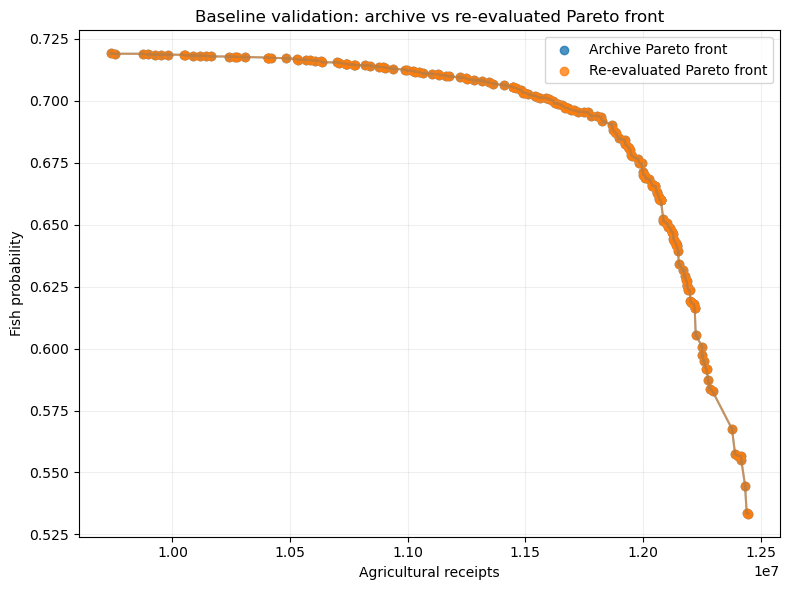

Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/200_validate_fish_dollars_baseline_reevaluation/200_validation_pareto_overlay.png


In [7]:
def plot_one_to_one(df, xcol, ycol, title, outfile):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(df[xcol], df[ycol], alpha=0.7)
    mn = min(df[xcol].min(), df[ycol].min())
    mx = max(df[xcol].max(), df[ycol].max())
    ax.plot([mn, mx], [mn, mx], linestyle="--")
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.set_title(title)
    ax.grid(True, alpha=0.2)
    fig.tight_layout()
    fig.savefig(outfile, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", outfile)

def plot_pareto_overlay(df, outfile):
    plot_df = df.copy().sort_values("ag_receipts_archive")

    fig, ax = plt.subplots(figsize=(8, 6))

    ax.scatter(
        plot_df["ag_receipts_archive"],
        plot_df["fish_prob_archive"],
        alpha=0.8,
        label="Archive Pareto front"
    )
    ax.plot(
        plot_df["ag_receipts_archive"],
        plot_df["fish_prob_archive"],
        alpha=0.6
    )

    ax.scatter(
        plot_df["ag_receipts_reeval"],
        plot_df["fish_prob_reeval"],
        alpha=0.8,
        label="Re-evaluated Pareto front"
    )
    ax.plot(
        plot_df["ag_receipts_reeval"],
        plot_df["fish_prob_reeval"],
        alpha=0.6
    )

    ax.set_xlabel("Agricultural receipts")
    ax.set_ylabel("Fish probability")
    ax.set_title("Baseline validation: archive vs re-evaluated Pareto front")
    ax.grid(True, alpha=0.2)
    ax.legend()

    fig.tight_layout()
    fig.savefig(outfile, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", outfile)

plot_one_to_one(
    comparison,
    "ag_receipts_archive",
    "ag_receipts_reeval",
    "Baseline validation: ag_receipts",
    OUTPUT_DIR / "200_validation_ag_receipts_one_to_one.png",
)

plot_one_to_one(
    comparison,
    "fish_prob_archive",
    "fish_prob_reeval",
    "Baseline validation: fish_prob",
    OUTPUT_DIR / "200_validation_fish_prob_one_to_one.png",
)

plot_pareto_overlay(
    comparison,
    OUTPUT_DIR / "200_validation_pareto_overlay.png",
)


## 8) Save validation outputs

In [8]:

comparison.to_csv(OUTPUT_DIR / "200_baseline_reevaluation_comparison.csv", index=False)
summary.to_csv(OUTPUT_DIR / "200_baseline_reevaluation_validation_summary.csv", index=False)

if not error_df.empty:
    error_df.to_csv(OUTPUT_DIR / "200_baseline_reevaluation_errors.csv", index=False)

print("Saved files:")
for f in sorted(OUTPUT_DIR.glob("*")):
    print(" -", f)

Saved files:
 - /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/200_validate_fish_dollars_baseline_reevaluation/200_baseline_reevaluation_comparison.csv
 - /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/200_validate_fish_dollars_baseline_reevaluation/200_baseline_reevaluation_validation_summary.csv
 - /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/200_validate_fish_dollars_baseline_reevaluation/200_validation_ag_receipts_one_to_one.png
 - /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/200_validate_fish_dollars_baseline_reevaluation/200_validation_fish_prob_one_to_one.png
 - /workspaces/LPR_redux/LPR_pycap_opt/notebooks/project_output/200_validate_fish_dollars_baseline_reevaluation/200_validation_pareto_overlay.png


## 9) Interpretation guide

### If validation passed is `True`

Great. That means we can trust the source-of-truth fish-dollars re-evaluation workflow. The next notebook should be:

`201_reevaluate_baseline_designs_across_T_sweep.ipynb`

That notebook will keep the same baseline Pareto designs, change transmissivity, and calculate the cost of wrongness.

### If validation passed is `False`

Do not continue to the ±10% or probability-weighted analysis yet. First inspect:

1. `200_baseline_reevaluation_comparison.csv`
2. `200_baseline_reevaluation_validation_summary.csv`
3. `200_baseline_reevaluation_errors.csv`, if it exists

The most likely causes are:

- the wrong `dv_pop` file was matched to the Pareto member names,
- the run folder does not correspond to the selected Pareto summary,
- the notebook is being run from the wrong repo/folder,
- the original run script has changed relative to the historical run outputs.